In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
import glob
import torch
import numpy as np


from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from monai.data import Dataset, DataLoader, CacheDataset, DataLoader, partition_dataset
from monai.bundle import download, load,ConfigParser
from monai.transforms import (
    Compose, LoadImaged, ScaleIntensityd, ToTensord,EnsureChannelFirstd,RandCropByPosNegLabeld,
    RandRotate90d, RandFlipd, RandZoomd, RandGaussianNoised, CropForegroundd
)


/Users/anshikabajpai/Desktop/prostate gland segmentation/Prostate_Gland_segmentation/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_determinism(seed=0)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
%%capture
# import huggingface_hub
bundle_dir = "prostate_mri_anatomy"
download(name=bundle_dir, bundle_dir=".", progress=True)

In [ ]:
#Macos MPS support (uncomment the following lines if using a Mac with MPS support)

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")

In [ ]:
bundle_dir = "prostate_mri_anatomy"
model_path = os.path.join(bundle_dir, "models", "model.pt")
print(model_path)

In [ ]:
print(os.listdir(bundle_dir))
# models directory
models_dir = os.path.join(bundle_dir, "models")
if os.path.exists(models_dir):
    print(os.listdir(models_dir))

In [ ]:
#get the model weights and parse the config file
config_parser = ConfigParser()
config_file = os.path.join(bundle_dir, "configs", "train.json")
print(config_file)
if os.path.exists(config_file):
    model = torch.load(model_path, map_location=device)

    config_parser.read_config(config_file)
    network_def=config_parser.get_parsed_content("network_def", instantiate=True)
    network_def.load_state_dict(model)
    model=network_def
    print(config_parser.get("network_def", default=None))
    model.eval()
    model=model.to(device)

    print("Model loaded successfully!")

To run inference for Dataset D2

In [ ]:
!python -m monai.bundle run \
    --config_file prostate_mri_anatomy/configs/inference.json \
    --ckpt_path /prostate_mri_anatomy/models/model.pt 


Visualizations:

In [ ]:
import nibabel as nib

# Load the file
file_path = "eval/10040_t2w/10040_t2w_trans.nii.gz"
img = nib.load(file_path)

# Get image data as a NumPy array
data = img.get_fdata()
print("Shape of the image:", data.shape)


import matplotlib.pyplot as plt

# Visualize middle slice in the Z-axis
middle_slice = data[:, :, data.shape[2] // 2]

plt.imshow(middle_slice.T, cmap="gray", origin="lower")
plt.title("Middle Slice")
plt.axis("off")
plt.show()


for i in range(0, data.shape[2], 10):  # every 10th slice
    plt.imshow(data[:, :, i].T, cmap="gray", origin="lower")
    plt.title(f"Slice {i}")
    plt.axis("off")
    plt.show()




Comparison visualizations:

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

# Paths
input_paths = [ "file_data/10040/10040_t2w.nii.gz",  "file_data/10043/10043_t2w.nii.gz",  "file_data/10005/10005_t2w.nii.gz"]
eval_paths = ["eval/10040_t2w/10040_t2w_trans.nii.gz", "eval/10043_t2w/10043_t2w_trans.nii.gz", "eval/10005_t2w/10005_t2w_trans.nii.gz"]


# Load NIfTI images
for input_path, eval_path in zip(input_paths, eval_paths):
    input_img = nib.load(input_path)
    eval_img = nib.load(eval_path)

    # Get data arrays
    input_data = input_img.get_fdata()
    eval_data = eval_img.get_fdata()

    # Check shapes
    print("Input shape:", input_data.shape)
    print("Eval shape:", eval_data.shape)
    slice_idx = input_data.shape[2] // 2  # middle slice

    input_slice = input_data[:, :, slice_idx]
    eval_slice = eval_data[:, :, slice_idx]

    plt.figure(figsize=(12, 6))

    # Input image
    plt.subplot(1, 2, 1)
    plt.imshow(input_slice.T, cmap="gray", origin="lower")
    plt.title("Input T2W MRI")
    plt.axis("off")

    # Eval image
    plt.subplot(1, 2, 2)
    plt.imshow(eval_slice.T, cmap="gray", origin="lower")
    plt.title("Eval / Transformed Image")
    plt.axis("off")

    plt.show()

Training - Fine tuning

In [60]:
!python -m monai.bundle run --config_file prostate_mri_anatomy/configs/train.json


2025-12-03 09:57:53,336 - INFO - Setting logging properties based on config: prostate_mri_anatomy/configs/logging.conf.
/Users/anshikabajpai/Desktop/prostate_cancer/myenv/lib/python3.12/site-packages/monai/bundle/reference_resolver.py:226: UserWarning: Detected deprecated name 'optional_packages_version' in configuration file, replacing with 'required_packages_version'.
  warnings.warn(
Freezing encoder layers...
Unfreezing decoder and output layers...
2025-12-03 09:57:53,615 - INFO - --- input summary of monai.bundle.scripts.run ---
2025-12-03 09:57:53,615 - INFO - ---


/Users/anshikabajpai/Desktop/prostate_cancer/myenv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the 

To remove cache, otherwise the model will continue learning from previous run

In [ ]:
# # Remove cache completely
# rm -rf cache/
# rm -rf prostate_mri_anatomy/

# # Also check for any hidden cache in tmp
# rm -rf /tmp/monai_*
# rm -rf ~/.cache/monai*

In [59]:
rm -rf cache/

Basic debugging: (To check the model structure - Not using in the main code)

In [48]:
import torch
from monai.networks.nets import UNet

# Example: instantiate your network
network_def = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=[16, 32, 64, 128, 256, 512],
    strides=[2, 2, 2, 2, 2],
    num_res_units=4,
    norm='batch',
    act='prelu',
    dropout=0.15
)

# Move to device if needed
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
network_def.to(device)

# Check top-level attributes
print(dir(network_def))

# Check encoder and decoder blocks
print(network_def.conv_blocks_context)       # encoder
print(network_def.conv_blocks_localization)  # decoder
print(network_def.final_conv)                # final layer

# Optional: see parameters and whether requires_grad
for name, param in network_def.named_parameters():
    print(name, param.requires_grad)


['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_bottom_layer', '_get_connection_block', '_get_down_layer', '_get_name', '_get_up_layer', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members'

AttributeError: 'UNet' object has no attribute 'conv_blocks_context'

Model architecture - MonAI prostate

In [49]:
for i, layer in enumerate(network_def.model):
    print(i, layer)


0 ResidualUnit(
  (conv): Sequential(
    (unit0): Convolution(
      (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (adn): ADN(
        (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (D): Dropout(p=0.15, inplace=False)
        (A): PReLU(num_parameters=1)
      )
    )
    (unit1): Convolution(
      (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (adn): ADN(
        (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (D): Dropout(p=0.15, inplace=False)
        (A): PReLU(num_parameters=1)
      )
    )
    (unit2): Convolution(
      (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (adn): ADN(
        (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (D): Dropout(p=0.15, inplace=False)
        (A): PReLU(num_parameters=1)
      )
    )


In [53]:
# Check top-level attributes
print(dir(network_def))

# Check the type of model
print(type(network_def.model))

# Print out model children / submodules with indices
for i, layer in enumerate(network_def.model):
    print(f"{i}: {layer.__class__.__name__}")


['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_bottom_layer', '_get_connection_block', '_get_down_layer', '_get_name', '_get_up_layer', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members'

In [54]:
encoder_count = 0
for layer in network_def.model:
    for name, module in layer.named_modules():
        if isinstance(module, torch.nn.Conv3d) and any(s > 1 for s in module.stride):
            encoder_count += 1

print(f"Number of encoder layers: {encoder_count}")


Number of encoder layers: 10


Running inference after training:

In [2]:
!python -m monai.bundle run \
    --config_file prostate_mri_anatomy/configs/inference.json \
    --ckpt_path /prostate_mri_anatomy/models/model.pt 

2025-12-03 21:28:29,182 - INFO - Setting logging properties based on config: prostate_mri_anatomy/configs/logging.conf.
/Users/anshikabajpai/Desktop/prostate_cancer/myenv/lib/python3.12/site-packages/monai/bundle/reference_resolver.py:226: UserWarning: Detected deprecated name 'optional_packages_version' in configuration file, replacing with 'required_packages_version'.
  warnings.warn(
2025-12-03 21:28:29,185 - INFO - --- input summary of monai.bundle.scripts.run ---
2025-12-03 21:28:29,185 - INFO - > ckpt_path: '/prostate_mri_anatomy/models/model.pt'
2025-12-03 21:28:29,185 - INFO - ---


/Users/anshikabajpai/Desktop/prostate_cancer/myenv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to Non

Visualization of ground truth vs fine tuned

Input shape: (256, 256, 32)
Eval shape: (256, 256, 32)
gt shape: (256, 256, 32)


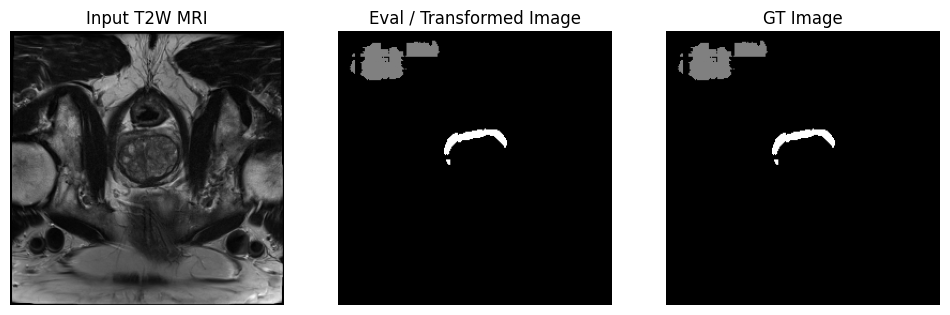

Input shape: (256, 256, 32)
Eval shape: (256, 256, 32)
gt shape: (256, 256, 32)


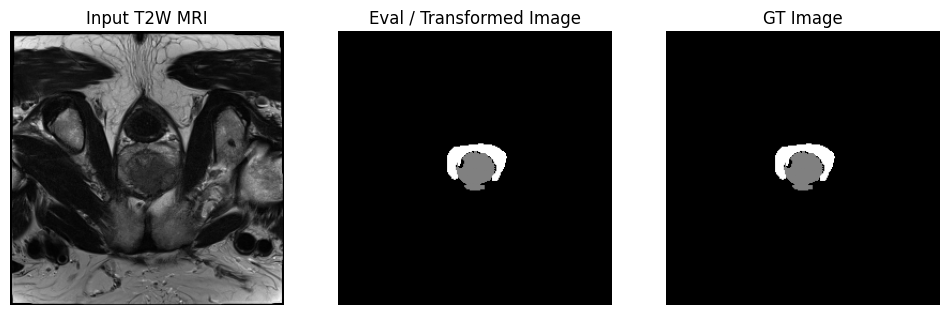

Input shape: (256, 256, 32)
Eval shape: (256, 256, 32)
gt shape: (256, 256, 32)


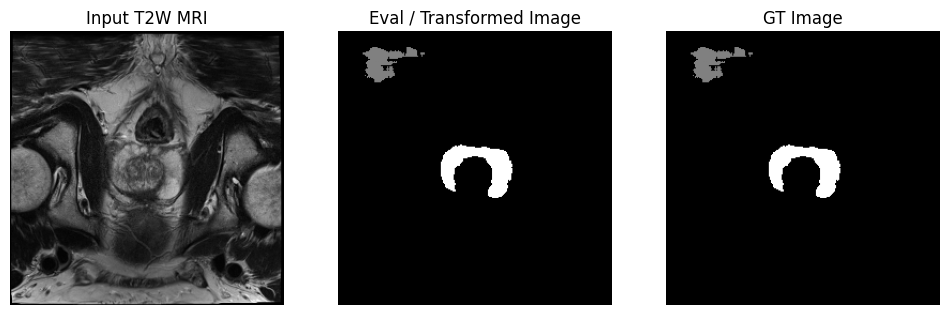

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt

# Paths
input_paths = [ "file_data/10040/10040_t2w.nii.gz",  "file_data/10043/10043_t2w.nii.gz",  "file_data/10005/10005_t2w.nii.gz"]
eval_paths = ["eval/10040_t2w/10040_t2w_trans.nii.gz", "eval/10043_t2w/10043_t2w_trans.nii.gz", "eval/10005_t2w/10005_t2w_trans.nii.gz"]
gt_paths = [ "file_data/10040/10040_gland.nii.gz",  "file_data/10043/10043_gland.nii.gz",  "file_data/10005/10005_gland.nii.gz"]


# Load NIfTI images
for input_path, eval_path,gt_path in zip(input_paths, eval_paths,gt_paths):
    input_img = nib.load(input_path)
    eval_img = nib.load(eval_path)
    gt_img = nib.load(gt_path)

    # Get data arrays
    input_data = input_img.get_fdata()
    eval_data = eval_img.get_fdata()
    gt_data = gt_img.get_fdata()

    # Check shapes
    print("Input shape:", input_data.shape)
    print("Eval shape:", eval_data.shape)
    print("gt shape:", gt_data.shape)
    slice_idx = input_data.shape[2] // 2  # middle slice

    input_slice = input_data[:, :, slice_idx]
    eval_slice = eval_data[:, :, slice_idx]
    gt_slice = gt_data[:, :, slice_idx]

    plt.figure(figsize=(12, 6))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(input_slice.T, cmap="gray", origin="lower")
    plt.title("Input T2W MRI")
    plt.axis("off")

    # Eval image
    plt.subplot(1, 3, 2)
    plt.imshow(eval_slice.T, cmap="gray", origin="lower")
    plt.title("Eval / Transformed Image")
    plt.axis("off")

    # Ground Truth image
    plt.subplot(1, 3, 3)
    plt.imshow(eval_slice.T, cmap="gray", origin="lower")
    plt.title("GT Image")
    plt.axis("off")

    plt.show()

Comparison of all the models:

In [4]:
import os
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

# ----------- PATHS -----------
csv_path = "test/test.csv"
result_dirs = {
    "Zero-Shot": "results_zer_shot",
    "simple_fine_tune": "results_fine_tune",
    "ce_dice+aug prob": "results_ce_dice",
    "low_lr": "results_low_lr"
}
gt_base_dir = "test/test"
input_base_dir = "test/test"
save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

# ----------- LOAD IDS FROM CSV -----------
df = pd.read_csv(csv_path)
ids = df["patientID"].astype(str).tolist()
print(f"Found {len(ids)} patients")

# ----------- LOOP THROUGH ALL IDS -----------
for pid in ids:
    try:
        # ----------- LOAD INPUT AND GT -----------
        input_path = os.path.join(input_base_dir, pid, f"{pid}_t2w.nii.gz")
        gt_path = os.path.join(gt_base_dir, pid, f"{pid}_gland.nii.gz")
        input_img = nib.load(input_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        # ----------- LOAD ALL MODEL RESULTS -----------
        model_data = {}
        for name, folder in result_dirs.items():
            model_path = os.path.join(folder, f"{pid}_t2w", f"{pid}_t2w_trans.nii.gz")
            model_data[name] = nib.load(model_path).get_fdata()

        # ----------- PICK MIDDLE SLICE -----------
        slice_idx = input_img.shape[2] // 2

        # ----------- PLOT ALL SIDE BY SIDE -----------
        total_cols = 2 + len(result_dirs)  # input + gt + all models
        plt.figure(figsize=(5 * total_cols, 5))

        # Input
        plt.subplot(1, total_cols, 1)
        plt.imshow(input_img[:, :, slice_idx], cmap="gray")
        plt.title("Input")
        plt.axis("off")

        # Model results
        for i, (name, data) in enumerate(model_data.items(), start=2):
            plt.subplot(1, total_cols, i)
            plt.imshow(data[:, :, slice_idx], cmap="gray")
            plt.title(name)
            plt.axis("off")

        # Ground truth
        plt.subplot(1, total_cols, total_cols)
        plt.imshow(gt[:, :, slice_idx], cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.suptitle(f"Patient ID: {pid}", fontsize=16)
        plt.tight_layout()

        # ----------- SAVE FIGURE -----------
        save_path = os.path.join(save_dir, f"{pid}_comparison.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved visualization for {pid} at {save_path}")

    except Exception as e:
        print(f"❌ Skipping {pid} due to error:", e)


Found 10 patients
✅ Saved visualization for 11256 at visualizations/11256_comparison.png
✅ Saved visualization for 11260 at visualizations/11260_comparison.png
✅ Saved visualization for 11278 at visualizations/11278_comparison.png
✅ Saved visualization for 11280 at visualizations/11280_comparison.png
✅ Saved visualization for 11284 at visualizations/11284_comparison.png
✅ Saved visualization for 11300 at visualizations/11300_comparison.png
✅ Saved visualization for 11361 at visualizations/11361_comparison.png
✅ Saved visualization for 11384 at visualizations/11384_comparison.png
✅ Saved visualization for 11444 at visualizations/11444_comparison.png
✅ Saved visualization for 11448 at visualizations/11448_comparison.png


Dice metric:

In [7]:
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ============================
# PATH CONFIG
# ============================
csv_path = "test/test.csv"

zero_shot_dir = "results_zer_shot"
fine_tune_dir = "results_fine_tune"
gt_base_dir = "test/test"
input_base_dir = "test/test"

# OPTIONAL: Save outputs instead of showing
SAVE_OUTPUTS = True
save_dir = "comparison_outputs"
os.makedirs(save_dir, exist_ok=True)

# ============================
# DICE FUNCTIONS
# ============================
def dice_score(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return (2. * intersection + eps) / (pred.sum() + gt.sum() + eps)

def dice_loss(pred, gt):
    return 1 - dice_score(pred, gt)

# ============================
# LOAD PATIENT IDS
# ============================
df = pd.read_csv(csv_path)
ids = df["patientID"].astype(str).tolist()

print(f"✅ Found {len(ids)} patients")

# ============================
# STORE RESULTS FOR CSV EXPORT
# ============================
results = []

# ============================
# MAIN LOOP
# ============================
for pid in ids:
    try:
        zero_shot_path = os.path.join(zero_shot_dir, f"{pid}_t2w", f"{pid}_t2w_trans.nii.gz")
        fine_tune_path = os.path.join(fine_tune_dir, f"{pid}_t2w", f"{pid}_t2w_trans.nii.gz")
        gt_path = os.path.join(gt_base_dir, pid, f"{pid}_gland.nii.gz")
        input_path = os.path.join(input_base_dir, pid, f"{pid}_t2w.nii.gz")

        # -------- LOAD VOLUMES --------
        zero_shot = nib.load(zero_shot_path).get_fdata()
        fine_tune = nib.load(fine_tune_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()
        input_img = nib.load(input_path).get_fdata()

        # -------- BINARIZE PREDICTIONS --------
        zero_shot_bin = (zero_shot > 0.5).astype(np.uint8)
        fine_tune_bin = (fine_tune > 0.5).astype(np.uint8)

        gt = (gt > 0).astype(np.uint8)

        # -------- COMPUTE DICE --------
        dice_zero = dice_score(zero_shot_bin, gt)
        dice_fine = dice_score(fine_tune_bin, gt)

        loss_zero = dice_loss(zero_shot_bin, gt)
        loss_fine = dice_loss(fine_tune_bin, gt)

        print(f"🧠 Patient {pid}")
        print(f"Zero-Shot Dice: {dice_zero:.4f} | Loss: {loss_zero:.4f}")
        print(f"Fine-Tune Dice: {dice_fine:.4f} | Loss: {loss_fine:.4f}")
        print("-" * 50)

        results.append([pid, dice_zero, loss_zero, dice_fine, loss_fine])

        # -------- SLICE SELECTION --------
        slice_idx = zero_shot.shape[2] // 2

        # -------- PLOT --------
        plt.figure(figsize=(22, 6))

        plt.subplot(1, 4, 1)
        plt.imshow(input_img[:, :, slice_idx], cmap="gray")
        plt.title(f"{pid} | Input")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(zero_shot_bin[:, :, slice_idx], cmap="gray")
        plt.title("Zero-Shot (Binarized)")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(fine_tune_bin[:, :, slice_idx], cmap="gray")
        plt.title("Fine-Tuned (Binarized)")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(gt[:, :, slice_idx], cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.suptitle(
            f"Patient {pid} | ZS Dice: {dice_zero:.3f} | FT Dice: {dice_fine:.3f}",
            fontsize=16
        )

        plt.tight_layout()

        if SAVE_OUTPUTS:
            out_path = os.path.join(save_dir, f"{pid}_comparison.png")
            plt.savefig(out_path, dpi=200)
            plt.close()
        else:
            plt.show()

    except Exception as e:
        print(f"❌ Skipping {pid} due to error: {e}")

# ============================
# SAVE DICE RESULTS TO CSV
# ============================
results_df = pd.DataFrame(
    results,
    columns=[
        "patientID",
        "dice_zero_shot",
        "dice_loss_zero_shot",
        "dice_fine_tune",
        "dice_loss_fine_tune",
    ],
)

results_df.to_csv("dice_results.csv", index=False)
print("✅ Dice results saved to dice_results.csv")


✅ Found 10 patients
🧠 Patient 11256
Zero-Shot Dice: 0.1166 | Loss: 0.8834
Fine-Tune Dice: 0.0554 | Loss: 0.9446
--------------------------------------------------
🧠 Patient 11260
Zero-Shot Dice: 0.0233 | Loss: 0.9767
Fine-Tune Dice: 0.0038 | Loss: 0.9962
--------------------------------------------------
🧠 Patient 11278
Zero-Shot Dice: 0.0444 | Loss: 0.9556
Fine-Tune Dice: 0.0114 | Loss: 0.9886
--------------------------------------------------
🧠 Patient 11280
Zero-Shot Dice: 0.0276 | Loss: 0.9724
Fine-Tune Dice: 0.0227 | Loss: 0.9773
--------------------------------------------------
🧠 Patient 11284
Zero-Shot Dice: 0.0098 | Loss: 0.9902
Fine-Tune Dice: 0.0051 | Loss: 0.9949
--------------------------------------------------
🧠 Patient 11300
Zero-Shot Dice: 0.0856 | Loss: 0.9144
Fine-Tune Dice: 0.0462 | Loss: 0.9538
--------------------------------------------------
🧠 Patient 11361
Zero-Shot Dice: 0.0045 | Loss: 0.9955
Fine-Tune Dice: 0.0007 | Loss: 0.9993
------------------------------